# Load , Explore and Clean Chess_games

In [1]:
# load chess from URL
import sys
sys.path.append('../src')
from fetch_data import load_data

url = 'https://drive.google.com/file/d/1eR3NZtwIC6ECN3vhtrynqmx8okG0twA7/view?usp=sharing'
file_id = url.split('/')[5]
url = f'https://drive.google.com/uc?id={file_id}'

games_df = load_data(url, '../data/raw/chess_games.csv')

Loading from cache: ../data/raw/chess_games.csv


#### Q1: How many records are in the dataset?

In [2]:
games_df.shape

(20058, 17)

- Q1: How many records are in the dataset?
  - 20,058 rows

#### Q2: How many exact duplicate rows exist?

In [3]:
games_df.duplicated().sum()

np.int64(0)

- Q2: How many exact duplicate rows exist?
  - 0 duplicated rows

#### Q3: How many games have duplicate move sequences?

In [4]:

duplicate_games = games_df.duplicated(subset='moves').sum()
print(duplicate_games)

1138


- Q3: How many games have duplicate move sequences?
   - 1,138

#### Q4: What % of opening_response is missing?

In [5]:
games_df['opening_response'].isna().sum() / len(games_df) *100

np.float64(93.982450892412)

- Q4: What % of opening_response is missing?
   - 93.98%

#### Q5: What % of opening_variation is missing?

In [6]:
games_df['opening_variation'].isna().sum() / len(games_df) *100

np.float64(28.218167314787117)

- Q5: What % of opening_variation is missing?
   - 28.21%

#### Q6: What is the minimum number of turns in any game? Why is this suspicious?

In [7]:
games_df['turns'].min()

np.int64(1)

In [8]:
games_df.loc[games_df['turns'].idxmin()]

game_id                           1947
rated                             True
turns                                1
victory_status                  Resign
winner                           Black
time_increment                    10+0
white_id                  serik-astana
white_rating                      1464
black_id                    brorael357
black_rating                      1355
moves                               g3
opening_code                       A00
opening_moves                        1
opening_fullname     Hungarian Opening
opening_shortname    Hungarian Opening
opening_response                   NaN
opening_variation                  NaN
Name: 1946, dtype: object

- Q6: What is the minimum number of turns in any game? Why is this suspicious?
   - 1 turn ,  One move then resign/time out.

In [9]:
import sys
sys.path.append('../src')
from clean_chess import clean_chess

In [10]:
games_df = clean_chess(games_df)
print("Clean done! Shape:", games_df.shape)
print("Columns:", games_df.columns.tolist())

Clean done! Shape: (20058, 22)
Columns: ['game_id', 'rated', 'turns', 'victory_status', 'winner', 'time_increment', 'white_id', 'white_rating', 'black_id', 'black_rating', 'moves', 'opening_code', 'opening_moves', 'opening_fullname', 'opening_shortname', 'opening_response', 'opening_variation', 'time_base', 'time_inc', 'rating_diff', 'opening_family', 'is_suspicious']


#### Q7: After adding rating_diff, what % of games did the higher-rated player win?

In [11]:
games_df['winner'].value_counts(normalize = True)

winner
White    0.498604
Black    0.454033
Draw     0.047363
Name: proportion, dtype: float64

In [12]:
non_draw = games_df[games_df['winner']!= 'Draw']
non_draw

,game_id,rated,turns,victory_status,winner,time_increment,white_id,white_rating,black_id,black_rating,...,opening_moves,opening_fullname,opening_shortname,opening_response,opening_variation,time_base,time_inc,rating_diff,opening_family,is_suspicious
0,1,False,13,Out of Time,White,15+2,bourgris,1500,a-00,1191,...,5,Slav Defense: Exchange Variation,Slav Defense,NaN,Exchange Variation,15,2,309,Slav Defense,False
1,2,True,16,Resign,Black,5+10,a-00,1322,skinnerua,1261,...,4,Nimzowitsch Defense: Kennedy Variation,Nimzowitsch Defense,NaN,Kennedy Variation,5,10,61,Nimzowitsch Defense,False
2,3,True,61,Mate,White,5+10,ischia,1496,a-00,1500,...,3,King's Pawn Game: Leonardis Variation,King's Pawn Game,NaN,Leonardis Variation,5,10,4,King's Pawn Game,False
3,4,True,61,Mate,White,20+0,daniamurashov,1439,adivanov2009,1454,...,3,Queen's Pawn Game: Zukertort Variation,Queen's Pawn Game,NaN,Zukertort Variation,20,0,15,Queen's Pawn Game,False
4,5,True,95,Mate,White,30+3,nik221107,1523,adivanov2009,1469,...,5,Philidor Defense,Philidor Defense,NaN,NaN,30,3,54,Philidor Defense,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20053,20054,True,24,Resign,White,10+10,belcolt,1691,jamboger,1220,...,2,Dutch Defense,Dutch Defense,NaN,NaN,10,10,471,Dutch Defense,False
20054,20055,True,82,Mate,Black,10+0,jamboger,1233,farrukhasomiddinov,1196,...,2,Queen's Pawn,Queen's Pawn,NaN,NaN,10,0,37,Queen's Pawn,False
20055,20056,True,35,Mate,White,10+0,jamboger,1219,schaaksmurf3,1286,...,3,Queen's Pawn Game: Mason Attack,Queen's Pawn Game,NaN,Mason Attack,10,0,67,Queen's Pawn Game,False
20056,20057,True,109,Resign,White,10+0,marcodisogno,1360,jamboger,1227,...,4,Pirc Defense,Pirc Defense,NaN,NaN,10,0,133,Pirc Defense,False


In [13]:
higher_rated_won = (
    ((non_draw['winner'] == 'White') & (non_draw['rating_diff'] > 0)) |
    ((non_draw['winner'] == 'Black') & (non_draw['rating_diff'] < 0))
)
print(f"Q7: {higher_rated_won.mean() * 100:.1f}% of non-draw games")

Q7: 51.8% of non-draw games


#### Q8: How many games are flagged as suspicious (< 5 turns)?

In [14]:
print(f"{games_df['is_suspicious'].sum()} games")

342 games


#### Q9: How many unique opening families exist?

In [15]:
games_df['opening_family'].nunique()

227

#### Q10 : Win rate for White, Black, Draw (% of total games)

In [16]:
games_df['winner'].value_counts(normalize=True).mul(100).round(2)

winner
White    49.86
Black    45.40
Draw      4.74
Name: proportion, dtype: float64

#### Q11: Most common victory_status

In [17]:
games_df['victory_status'].value_counts(normalize= True).mul(100).round(2)

victory_status
Resign         55.57
Mate           31.53
Out of Time     8.38
Draw            4.52
Name: proportion, dtype: float64

#### Q12: victory_status with highest average turns

In [18]:
games_df.groupby('victory_status')['turns'].mean().sort_values(ascending=False).round(2)

victory_status
Draw           83.78
Out of Time    72.74
Mate           65.42
Resign         53.91
Name: turns, dtype: float64

#### Q13: Most popular opening family when Black wins / White wins

In [19]:
subset = games_df[games_df['winner'] == 'White']['opening_family']
counts = subset.value_counts()
top = counts.idxmax()
count = counts.iloc[0]
print(f"White wins -> {top} ({count} games)")

White wins -> Sicilian Defense (1173 games)


In [20]:
subset = games_df[games_df['winner'] == 'Black']['opening_family']
counts = subset.value_counts()
top = counts.idxmax()
count = counts.iloc[0]
print(f"Black wins -> {top} ({count} games)")

Black wins -> Sicilian Defense (1273 games)


#### Q14 — Rated vs Unrated White win rate

In [21]:
for rated_val, label in [(True, 'Rated'), (False, 'Unrated')]:
    mask = games_df['rated'] == rated_val
    rate = (games_df[mask]['winner'] == 'White').mean() * 100
    print(f"  {label}: {rate:.2f}%")

  Rated: 49.84%
  Unrated: 49.94%


#### Q15 — Classify Short / Medium / Long using apply()

In [22]:
def classify_game(turns):
    if turns < 20:
        return 'Short'
    elif turns <= 40:
        return 'Medium'
    else:
        return 'Long'

games_df['game_length'] = games_df['turns'].apply(classify_game)
print(games_df['game_length'].value_counts(normalize = True).mul(100).round(2))

game_length
Long      70.37
Medium    21.35
Short      8.28
Name: proportion, dtype: float64


In [23]:
games_df.columns

Index(['game_id', 'rated', 'turns', 'victory_status', 'winner',
       'time_increment', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_code', 'opening_moves',
       'opening_fullname', 'opening_shortname', 'opening_response',
       'opening_variation', 'time_base', 'time_inc', 'rating_diff',
       'opening_family', 'is_suspicious', 'game_length'],
      dtype='object')

In [24]:
from clean_chess import clean_chess
games_cleaned = clean_chess(games_df)
games_cleaned.to_csv('../data/processed/chess_games_clean.csv', index= False)

# Load , Explore and Clean players_registry

In [24]:
url = 'https://drive.google.com/file/d/1wCSAkGagMzWiToedLC3ZGo_lGf_laF-k/view?usp=sharing'
file_id = url.split('/')[5]
url = f'https://drive.google.com/uc?id={file_id}'

players_df = load_data(url, '../data/raw/player_registry.csv')

Loading from cache: ../data/raw/player_registry.csv


In [25]:
players_df.shape

(215, 9)

In [26]:
players_df.head(5)

,username,display_name,country,registered_year,rating_registry,total_games_registry,account_status,email_verified,join_platform
0,taranga,Taranga,UA,2019.0,1431,162,NaN,True,lichess
1,a_p_t_e_m_u_u,A P T E M U U,BRA,2021.0,1264,104,active,False,lichess
2,vladimir-kramnik-1,Vladimir Kramnik 1,united kingdom,2022.0,1573,101,active,True,lichess
3,king5891,King5891,Russia,2022.0,1400,87,active,False,chess.com
4,saviter,Saviter,India,2015.0,1730,85,active,True,lichess


In [27]:
players_df.columns

Index(['username', 'display_name', 'country', 'registered_year',
       'rating_registry', 'total_games_registry', 'account_status',
       'email_verified', 'join_platform'],
      dtype='object')

In [28]:
players_df.isnull().sum()

username                 0
display_name             0
country                 14
registered_year          7
rating_registry          0
total_games_registry     0
account_status          46
email_verified           0
join_platform            0
dtype: int64

#### Q17 — How many country name inconsistencies exist (e.g. 'US'/'USA'/'United States')?

In [29]:
players_df['country'].unique()

array(['UA', 'BRA', 'united kingdom', 'Russia', 'India', 'Spain', 'RUS',
       'Brazil', 'Germany', 'US', nan, 'USA', 'Ukraine', 'Poland',
       'united states', 'France', 'poland', 'russian federation', 'FR',
       'Deutschland', 'france', 'DE', 'brazil', 'United Kingdom',
       'United States', 'GB', 'IN', 'PL', 'ES', 'UK'], dtype=object)

In [30]:
country_map = {
    # Russia
    'RUS': 'Russia', 'russian federation': 'Russia',
    
    # United States
    'US': 'United States', 'USA': 'United States',
    'united states': 'United States',
    
    # Ukraine
    'UA': 'Ukraine',
    
    # Brazil
    'BRA': 'Brazil', 'brazil': 'Brazil',
    
    # United Kingdom
    'GB': 'United Kingdom', 'UK': 'United Kingdom',
    'united kingdom': 'United Kingdom',
    
    # Germany
    'DE': 'Germany', 'Deutschland': 'Germany',
    
    # France
    'FR': 'France', 'france': 'France',
    
    # Poland
    'PL': 'Poland', 'poland': 'Poland',
    
    # India
    'IN': 'India',
    
    # Spain
    'ES': 'Spain',
}

players_df['country'] = players_df['country'].map(country_map).fillna(players_df['country'])

print(players_df['country'].unique())

['Ukraine' 'Brazil' 'United Kingdom' 'Russia' 'India' 'Spain' 'Germany'
 'United States' nan 'Poland' 'France']


- 10 unique countries

#### Merge the two datasets

In [31]:
import pandas as pd
merged = pd.merge(
    games_df[['game_id', 'white_id', 'white_rating', 'winner', 'turns', 'rated']],
    players_df[['username', 'country']].rename(columns={'username': 'white_id'}),
    on='white_id',
    how='left'
)

In [32]:
merged.head()

,game_id,white_id,white_rating,winner,turns,rated,country
0,1,bourgris,1500,White,13,False,NaN
1,2,a-00,1322,Black,16,True,NaN
2,3,ischia,1496,White,61,True,NaN
3,4,daniamurashov,1439,White,61,True,NaN
4,5,nik221107,1523,White,95,True,NaN


In [33]:
merged.shape

(20058, 7)

#### Q16 — How many white players in the chess data have no registry entry ?

In [34]:
merged[merged['country'].isna()]['white_id'].nunique()

9251

#### Q18 — Plot: bar chart of win counts by color. Save to output/wins_by_color.png

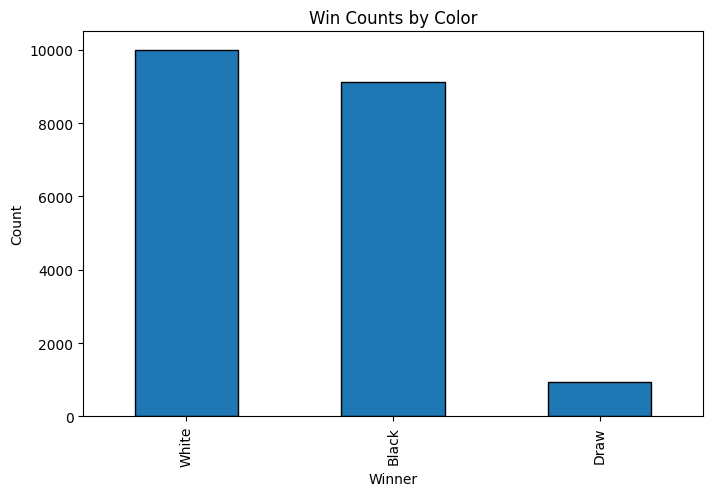

In [35]:
import os
os.makedirs('../output', exist_ok=True)
ax = merged['winner'].value_counts().plot(
    kind='bar',
    edgecolor='black',
    figsize=(8, 5),
    title='Win Counts by Color'
)

ax.set_xlabel('Winner')
ax.set_ylabel('Count')

ax.figure.savefig('../output/wins_by_color.png')

#### Q19 — Plot: scatter of white_rating vs turns for rated games. What do you observe?


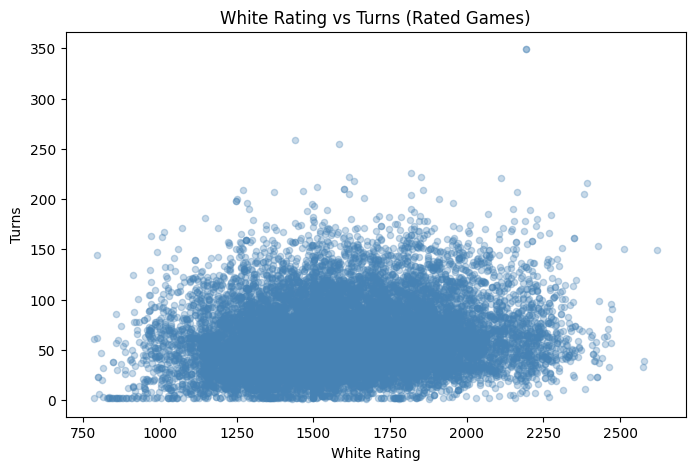

In [36]:
rated = merged[merged['rated'] == True]

ax = rated.plot(
    kind='scatter',
    x='white_rating',
    y='turns',
    alpha=0.3,
    color='steelblue',
    figsize=(8, 5),
    title='White Rating vs Turns (Rated Games)'
)

ax.set_xlabel('White Rating')
ax.set_ylabel('Turns')

ax.figure.savefig('../output/white_rating_vs_turns.png')

#### Q19 Observation:
- Most games end between 25-120 turns regardless of rating
- Beginner players (rating < 1000) tend to have shorter games
- Mid-level players (1200-1800) show the most variation in turn count
- High-rated players (rating > 2000) have fewer games but more consistent turn counts
- There are clear outliers — some games reached up to 350 turns!

#### Q20: Boxplot turns by victory_status

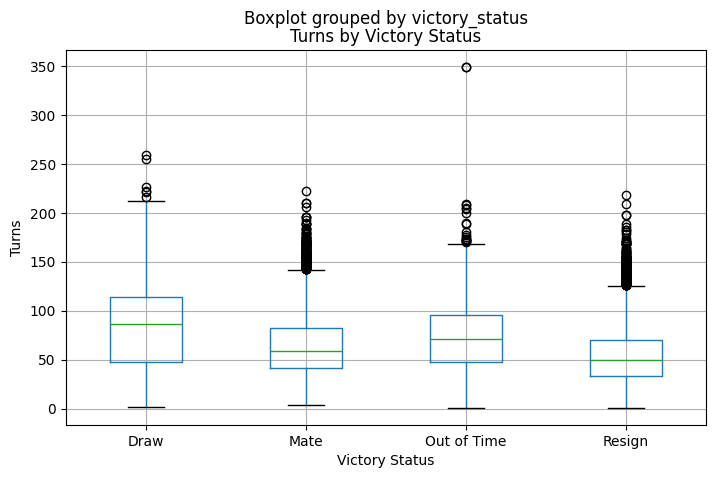

In [37]:
ax = games_df.boxplot(
    column='turns',
    by='victory_status',
    figsize=(8, 5)
)

ax.set_title('Turns by Victory Status')
ax.set_xlabel('Victory Status')
ax.set_ylabel('Turns')

ax.figure.savefig('../output/turns_by_victory_status.png')

#### Observation:
- Draw games have the highest median turns (~88) — they last the longest
- Out of Time is second (~70 turns)
- Mate games have a median of ~60 turns
- Resign games are the shortest (~50 turns) — players give up early
- All categories have outliers, with Out of Time reaching 350 turns!

# Data Visualization

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

#### Pivot_bar:

In [39]:
# pivot table for chess data 
pivot = games_df.pivot_table(
    values='turns',
    index='victory_status',
    columns='winner',
    aggfunc='mean'
).round(1).reset_index()
pivot

winner,victory_status,Black,Draw,White
0,Draw,NaN,83.8,NaN
1,Mate,67.3,NaN,63.8
2,Out of Time,70.9,135.1,71.2
3,Resign,55.5,NaN,52.5


In [40]:
# melt
long = pivot.melt(id_vars= 'victory_status', var_name='winner', value_name= 'avg_turns')
long

,victory_status,winner,avg_turns
0,Draw,Black,NaN
1,Mate,Black,67.3
2,Out of Time,Black,70.9
3,Resign,Black,55.5
4,Draw,Draw,83.8
5,Mate,Draw,NaN
6,Out of Time,Draw,135.1
7,Resign,Draw,NaN
8,Draw,White,NaN
9,Mate,White,63.8


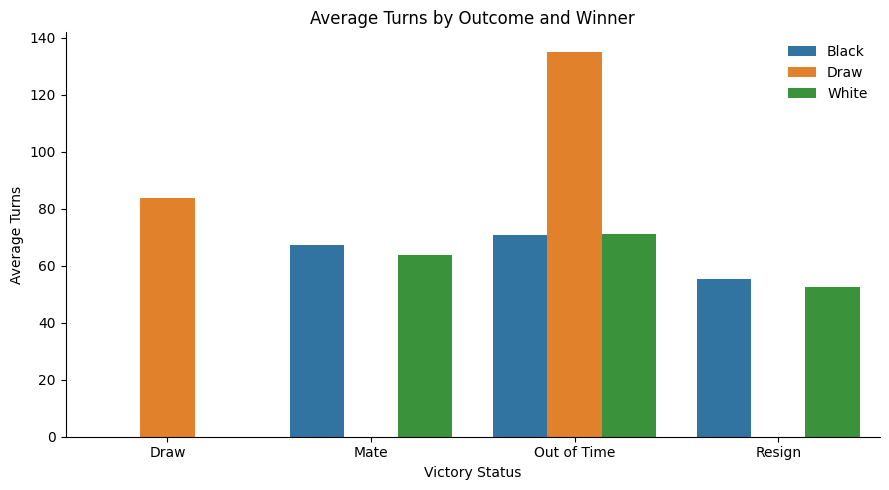

In [41]:
# Plot
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=long, x='victory_status', y='avg_turns', hue='winner', ax=ax)

ax.set_title('Average Turns by Outcome and Winner')
ax.set_xlabel('Victory Status')
ax.set_ylabel('Average Turns')
ax.spines[['top','right']].set_visible(False)
ax.legend(frameon=False)

fig.tight_layout()
plt.savefig('../output/pivot_bar.png', dpi=150, bbox_inches='tight')

#### Rolling analysis , one player

In [42]:
player_counts = games_df['white_id'].value_counts()
players_15plus = player_counts[player_counts >= 15].index

chosen_player = players_15plus[0]
print(chosen_player, player_counts[chosen_player])

taranga 72


In [43]:
player = games_df[games_df['white_id'] == chosen_player].sort_values('game_id').reset_index(drop=True)
player

,game_id,rated,turns,victory_status,winner,time_increment,white_id,white_rating,black_id,black_rating,...,opening_moves,opening_fullname,opening_shortname,opening_variation,time_base,time_inc,rating_diff,opening_family,is_suspicious,game_length
0,193,False,124,Mate,Black,8+0,taranga,1283,whfo,1267,...,5,Sicilian Defense: Nyezhmetdinov-Rossolimo Attack,Sicilian Defense,Nyezhmetdinov-Rossolimo Attack,8,0,16,Sicilian Defense,False,Long
1,197,True,10,Mate,Black,10+0,taranga,1305,piroz_xucestih,1293,...,3,French Defense: Normal Variation,French Defense,Normal Variation,10,0,12,French Defense,False,Short
2,201,False,38,Mate,Black,15+15,taranga,1293,vikrant_dalvi,1466,...,5,Philidor Defense #3,Philidor Defense,#3,15,15,-173,Philidor Defense #3,False,Medium
3,203,True,111,Mate,White,7+2,taranga,1288,jamila1234,1232,...,3,Caro-Kann Defense,Caro-Kann Defense,NaN,7,2,56,Caro-Kann Defense,False,Long
4,204,True,28,Resign,Black,7+2,taranga,1289,hknight_chess,2108,...,9,Ruy Lopez: Morphy Defense | Tarrasch Variation,Ruy Lopez,Morphy Defense,7,2,-819,Ruy Lopez,False,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,19085,False,60,Resign,Black,7+2,taranga,1289,armourbuddy,1810,...,5,Sicilian Defense: Hyperaccelerated Fianchetto,Sicilian Defense,Hyperaccelerated Fianchetto,7,2,-521,Sicilian Defense,False,Long
68,19087,False,21,Out of Time,White,5+8,taranga,1289,snapper,1500,...,5,Philidor Defense #3,Philidor Defense,#3,5,8,-211,Philidor Defense #3,False,Medium
69,19089,True,159,Mate,White,15+1,taranga,1280,moon50,1485,...,6,Italian Game: Anti-Fried Liver Defense,Italian Game,Anti-Fried Liver Defense,15,1,-205,Italian Game,False,Long
70,19090,False,74,Resign,White,15+0,taranga,1280,italiantranslator,1211,...,4,Scandinavian Defense: Mieses-Kotroc Variation,Scandinavian Defense,Mieses-Kotroc Variation,15,0,69,Scandinavian Defense,False,Long


In [44]:
# Rolling + Expanding
player['rolling_5'] = player['white_rating'].rolling(window=5).mean()
player['expanding_avg'] = player['white_rating'].expanding().mean()

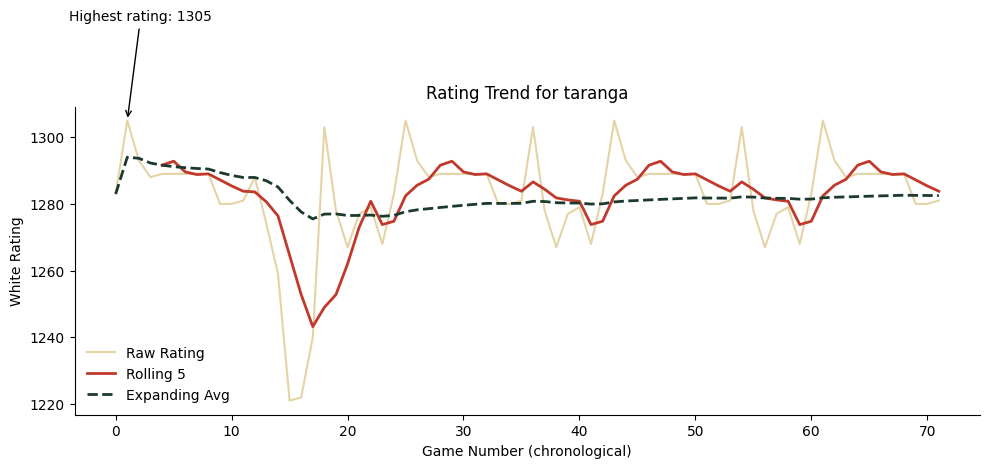

In [45]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(player.index, player['white_rating'], color='#C9A84C', alpha=0.5, label='Raw Rating')
ax.plot(player.index, player['rolling_5'], color='#C0392B', linewidth=2, label='Rolling 5')
ax.plot(player.index, player['expanding_avg'], color='#1B3A2D', linewidth=2, linestyle='--', label='Expanding Avg')

# Annotate highest-rated game
max_idx = player['white_rating'].idxmax()
max_rating = player.loc[max_idx, 'white_rating']
ax.annotate(f'Highest rating: {max_rating}',
             xy=(max_idx, max_rating),
             xytext=(max_idx - 5, max_rating + 30),
             arrowprops=dict(arrowstyle='->', color='black'))

ax.set_title(f'Rating Trend for {chosen_player}')
ax.set_xlabel('Game Number (chronological)')
ax.set_ylabel('White Rating')
ax.spines[['top','right']].set_visible(False)
ax.legend(frameon=False)

fig.tight_layout()
plt.savefig('../output/player_rolling.png', dpi=150, bbox_inches='tight')

#### Temperature time-series

In [46]:
temp = pd.read_csv("https://raw.githubusercontent.com/datasets/global-temp/main/data/annual.csv")
temp.to_csv('../data/raw/temp_annual.csv', index=False)

In [47]:
temp = pd.read_csv('../data/raw/temp_annual.csv')
gistemp = temp[temp['Source'] == 'GISTEMP'].copy()
gistemp['rolling_10'] = gistemp['Mean'].rolling(window=10, min_periods=1).mean()
gistemp.head()

,Source,Year,Mean,rolling_10
30,GISTEMP,1880,-0.1767,-0.17670
32,GISTEMP,1881,-0.0908,-0.13375
34,GISTEMP,1882,-0.1108,-0.12610
36,GISTEMP,1883,-0.1733,-0.13790
38,GISTEMP,1884,-0.2842,-0.16716


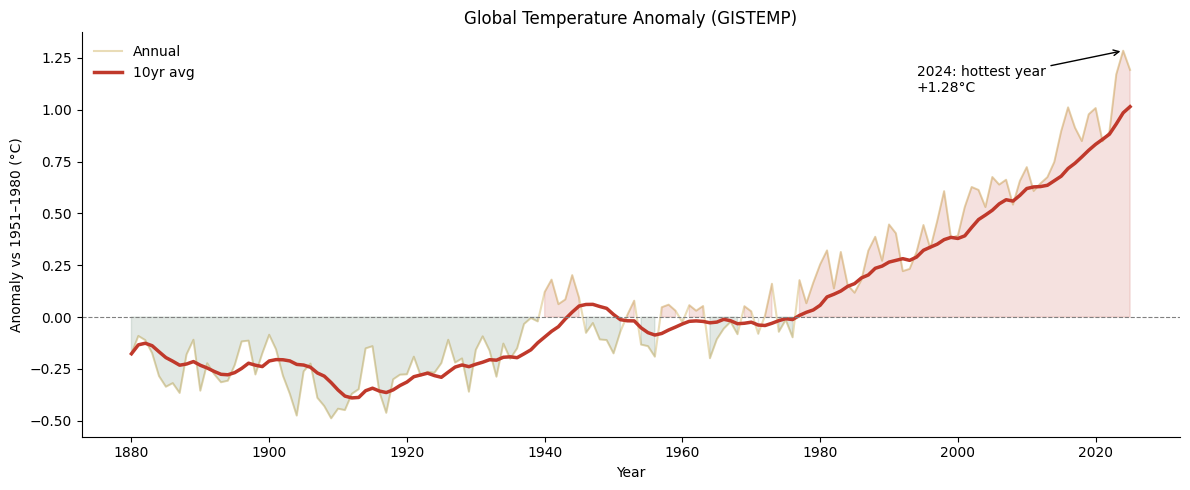

In [48]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(gistemp['Year'], gistemp['Mean'], color='#C9A84C', alpha=0.4, label='Annual')
ax.plot(gistemp['Year'], gistemp['rolling_10'], color='#C0392B', linewidth=2.5, label='10yr avg')

ax.axhline(y=0, color='grey', linewidth=0.8, linestyle='--')

ax.fill_between(gistemp['Year'], 0, gistemp['Mean'],
                where=gistemp['Mean'] > 0, alpha=0.15, color='#C0392B')
ax.fill_between(gistemp['Year'], 0, gistemp['Mean'],
                where=gistemp['Mean'] <= 0, alpha=0.15, color='#3D6B4F')

max_idx = gistemp['Mean'].idxmax()
max_year = gistemp.loc[max_idx, 'Year']
max_val = gistemp.loc[max_idx, 'Mean']

ax.annotate(f'{max_year}: hottest year\n+{max_val:.2f}°C',
             xy=(max_year, max_val),
             xytext=(max_year - 30, max_val - 0.2),
             arrowprops=dict(arrowstyle='->', color='black'))

ax.set_title('Global Temperature Anomaly (GISTEMP)')
ax.set_xlabel('Year')
ax.set_ylabel('Anomaly vs 1951–1980 (°C)')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)

fig.tight_layout()
plt.savefig('../output/temperature.png', dpi=150, bbox_inches='tight')

In [49]:
TEMP_MONTHLY_URL = "https://raw.githubusercontent.com/datasets/global-temp/main/data/monthly.csv"
temp_m = pd.read_csv(TEMP_MONTHLY_URL)

# working copy
temp_m2 = temp_m.copy()
temp_m2.columns

Index(['Source', 'Year', 'Mean'], dtype='object')

In [50]:
temp_m2.head()

,Source,Year,Mean
0,GCAG,1850-01,-0.7337
1,GCAG,1850-02,-0.3604
2,GCAG,1850-03,-0.6271
3,GCAG,1850-04,-0.6053
4,GCAG,1850-05,-0.5315


In [51]:
# convert Date column and extract year, month, decade
temp_m2['Date'] = pd.to_datetime(temp_m2['Year'])
temp_m2['year'] = temp_m2['Date'].dt.year
temp_m2['month'] = temp_m2['Date'].dt.month
temp_m2['decade'] = (temp_m2['year'] // 10) * 10
temp_m2.head()

,Source,Year,Mean,Date,year,month,decade
0,GCAG,1850-01,-0.7337,1850-01-01,1850,1,1850
1,GCAG,1850-02,-0.3604,1850-02-01,1850,2,1850
2,GCAG,1850-03,-0.6271,1850-03-01,1850,3,1850
3,GCAG,1850-04,-0.6053,1850-04-01,1850,4,1850
4,GCAG,1850-05,-0.5315,1850-05-01,1850,5,1850


In [52]:
# GISTEMP only
gm = temp_m2[temp_m2['Source'] == 'GISTEMP']

In [53]:
# pivot_table: rows = months, columns = decades
pivot = gm.pivot_table(index='month', columns='decade', values='Mean', aggfunc='mean')
pivot.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot

decade,1880,1890,1900,1910,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010,2020
Jan,-0.285,-0.337,-0.387,-0.327,-0.204,-0.136,0.110,-0.028,-0.071,0.043,0.320,0.405,0.605,0.802,1.070000
Feb,-0.234,-0.331,-0.308,-0.309,-0.274,-0.123,0.047,-0.067,-0.018,0.019,0.303,0.490,0.602,0.817,1.073333
Mar,-0.194,-0.303,-0.271,-0.366,-0.205,-0.163,0.033,-0.072,-0.034,0.067,0.300,0.453,0.657,0.912,1.185000
Apr,-0.204,-0.269,-0.308,-0.322,-0.288,-0.187,0.079,-0.059,-0.062,0.069,0.240,0.410,0.585,0.822,1.041667
May,-0.194,-0.243,-0.342,-0.343,-0.289,-0.166,0.047,-0.053,-0.041,0.050,0.265,0.348,0.547,0.785,0.966667
Jun,-0.236,-0.228,-0.323,-0.372,-0.317,-0.186,-0.018,-0.039,-0.009,0.027,0.196,0.417,0.540,0.729,1.010000
Jul,-0.169,-0.176,-0.305,-0.314,-0.261,-0.132,0.023,-0.034,-0.019,0.022,0.227,0.377,0.550,0.726,1.026667
Aug,-0.200,-0.199,-0.307,-0.321,-0.267,-0.122,0.009,-0.032,-0.014,0.012,0.241,0.343,0.557,0.802,1.046667
Sep,-0.208,-0.172,-0.316,-0.309,-0.231,-0.102,0.019,-0.035,-0.032,0.034,0.229,0.299,0.595,0.776,1.123333
Oct,-0.217,-0.157,-0.285,-0.288,-0.169,-0.036,0.102,-0.036,-0.005,0.008,0.194,0.352,0.601,0.848,1.116667


In [54]:
# filter years >= 1950
pivot_filtered = pivot[[c for c in pivot.columns if c >= 1950]]
pivot_filtered

decade,1950,1960,1970,1980,1990,2000,2010,2020
Jan,-0.028,-0.071,0.043,0.320,0.405,0.605,0.802,1.070000
Feb,-0.067,-0.018,0.019,0.303,0.490,0.602,0.817,1.073333
Mar,-0.072,-0.034,0.067,0.300,0.453,0.657,0.912,1.185000
Apr,-0.059,-0.062,0.069,0.240,0.410,0.585,0.822,1.041667
May,-0.053,-0.041,0.050,0.265,0.348,0.547,0.785,0.966667
Jun,-0.039,-0.009,0.027,0.196,0.417,0.540,0.729,1.010000
Jul,-0.034,-0.019,0.022,0.227,0.377,0.550,0.726,1.026667
Aug,-0.032,-0.014,0.012,0.241,0.343,0.557,0.802,1.046667
Sep,-0.035,-0.032,0.034,0.229,0.299,0.595,0.776,1.123333
Oct,-0.036,-0.005,0.008,0.194,0.352,0.601,0.848,1.116667


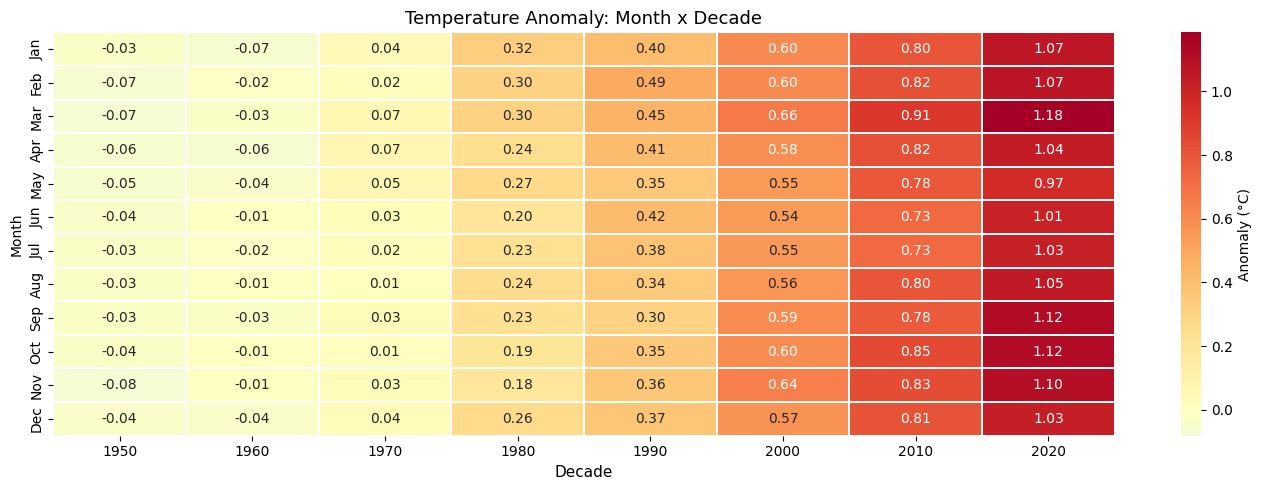

In [55]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_filtered, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Anomaly (°C)'})

ax.set_title('Temperature Anomaly: Month x Decade', fontsize=13)
ax.set_xlabel('Decade', fontsize=11)
ax.set_ylabel('Month')

fig.tight_layout()
plt.savefig('../output/heatmap.png', dpi=150, bbox_inches='tight')

#### Netflix EDA — 3 charts

In [56]:
netflix = pd.read_csv('../data/raw/netflix_titles.csv')
netflix

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


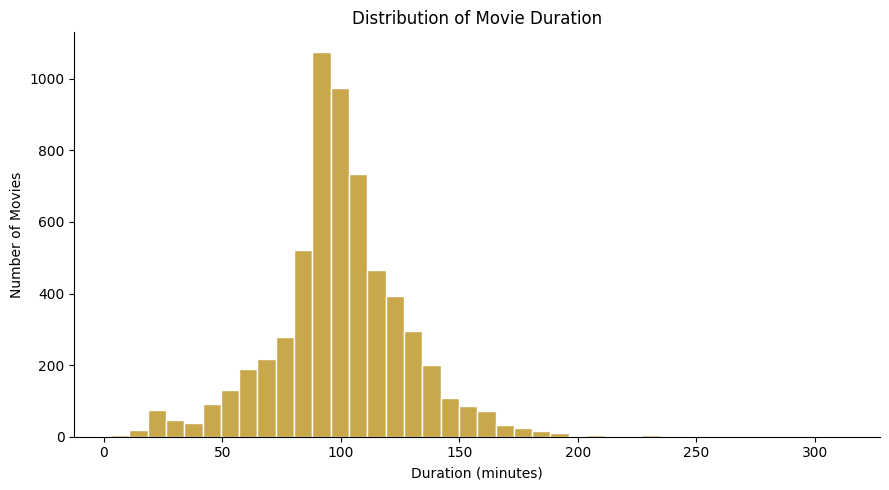

In [57]:
movies = netflix[netflix['type'] == 'Movie'].copy()

# extract numeric minutes from 'duration' (e.g. '90 min')
movies['duration_min'] = movies['duration'].str.extract(r'(\d+)').astype(float)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(movies['duration_min'].dropna(), bins=40, color='#C9A84C', edgecolor='white')

ax.set_title('Distribution of Movie Duration')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Number of Movies')
ax.spines[['top','right']].set_visible(False)

fig.tight_layout()
plt.savefig('../output/movie_duration.png', dpi=150, bbox_inches='tight')

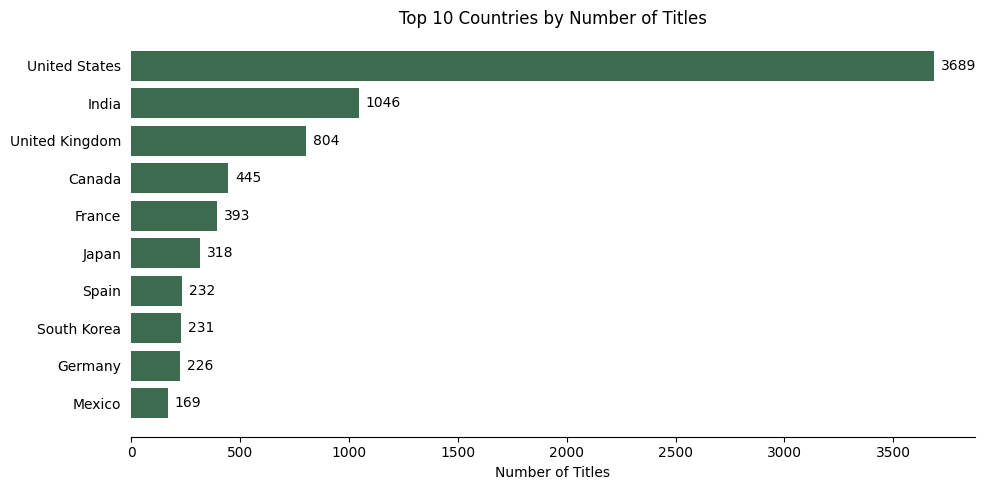

In [58]:
countries = (
    netflix['country'].dropna()
    .str.split(', ', expand=True)
    .stack()
    .reset_index(drop=True)
    .rename('country')
    .to_frame()
)

top10 = countries['country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10.index[::-1], top10.values[::-1], color='#3D6B4F')
ax.bar_label(bars, padding=5, fontsize=10)

ax.set_title('Top 10 Countries by Number of Titles')
ax.set_xlabel('Number of Titles')
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)

fig.tight_layout()
plt.savefig('../output/top_countries.png', dpi=150, bbox_inches='tight')

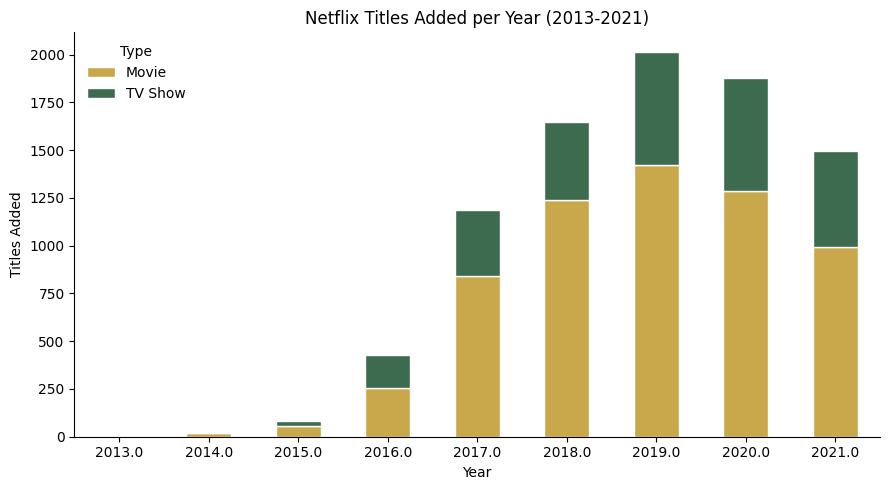

In [59]:
netflix['year_added'] = pd.to_datetime(netflix['date_added'].str.strip(), errors='coerce').dt.year

added = (
    netflix[netflix['year_added'].between(2013, 2021)]
    .groupby(['year_added', 'type']).size()
    .reset_index(name='count')
)

wide = added.pivot(index='year_added', columns='type', values='count').fillna(0)

fig, ax = plt.subplots(figsize=(9, 5))
wide.plot(kind='bar', stacked=True, ax=ax, color=['#C9A84C', '#3D6B4F'], edgecolor='white')

ax.set_title('Netflix Titles Added per Year (2013-2021)')
ax.set_xlabel('Year')
ax.set_ylabel('Titles Added')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Type', frameon=False)
ax.spines[['top','right']].set_visible(False)

fig.tight_layout()
plt.savefig('../output/stacked_year.png', dpi=150, bbox_inches='tight')

#### Statistics:

In [60]:
import pandas as pd

import numpy as np

from scipy import stats

df = pd.read_csv('../data/raw/chess_games.csv')

# Full profile

print(df['turns'].describe())

# count  20058  |  mean 60.5  |  std 34.1

# min 1  |  25% 36  |  50% 55  |  75% 77  |  max 349

# Mean vs median

print(f"Mean:   {df['turns'].mean():.1f}")    # 60.5

print(f"Median: {df['turns'].median():.1f}")  # 55.0  ← lower → right-skewed

# IQR

q1 = df['turns'].quantile(0.25)  # 36.0

q3 = df['turns'].quantile(0.75)  # 77.0

print(f"IQR:    {q3 - q1:.1f}")               # 41.0

# Skewness

print(f"Skew:   {df['turns'].skew():.2f}")    # 1.02  → right-skewed

count    20058.000000
mean        60.465999
std         33.570585
min          1.000000
25%         37.000000
50%         55.000000
75%         79.000000
max        349.000000
Name: turns, dtype: float64
Mean:   60.5
Median: 55.0
IQR:    42.0
Skew:   0.90


In [61]:
df['rolling_diff'] = abs(df['white_rating']- df['black_rating'])

In [62]:
df['rolling_diff'].describe()

count    20058.000000
mean       173.091435
std        179.214854
min          0.000000
25%         45.000000
50%        115.000000
75%        241.000000
max       1605.000000
Name: rolling_diff, dtype: float64

In [63]:
df['rolling_diff'].skew()

np.float64(1.94867622167178)

In [64]:
rated = df[df['rated'] == True]['turns']

unrated = df[df['rated'] == False]['turns']

print(f"Rated:   n={len(rated)}, mean={rated.mean():.1f}")    # mean=62.3

print(f"Unrated: n={len(unrated)}, mean={unrated.mean():.1f}")  # mean=51.7

# Welch's t-test (no equal-variance assumption — safer default)

t_stat, p_value = stats.ttest_ind(rated, unrated, equal_var=False)

print(f"t={t_stat:.3f}, p={p_value:.6f}")   # t≈10.5, p≈0.000000

# p < 0.05 → reject H0 → rated games ARE significantly longer

# Effect size — Cohen's d

pooled_std = np.sqrt((rated.std()**2 + unrated.std()**2) / 2)

cohen_d = (rated.mean() - unrated.mean()) / pooled_std

print(f"Cohen's d: {cohen_d:.3f}")   # ≈ 0.31 — SMALL effect

# Real, but modest: ~10 extra turns on average

# Non-parametric alternative (our data isn't normal)

u, p_mw = stats.mannwhitneyu(rated, unrated, alternative='two-sided')

print(f"Mann-Whitney p={p_mw:.6f}")  # confirms same conclusion

Rated:   n=16155, mean=62.0
Unrated: n=3903, mean=54.3
t=13.279, p=0.000000
Cohen's d: 0.233
Mann-Whitney p=0.000000


# Descriptive Statistics:

In [27]:
import pandas as pd

for col in ['turns', 'rating_diff']:

    q1 = games_cleaned[col].quantile(0.25)
    q3 = games_cleaned[col].quantile(0.75)

    print(f"\n----- {col} -----")
    print("Mean:", round(games_cleaned[col].mean(), 2))
    print("Median:", round(games_cleaned[col].median(), 2))
    print("Std:", round(games_cleaned[col].std(), 2))
    print("IQR:", round(q3 - q1, 2))
    print("Skewness:", round(games_cleaned[col].skew(), 2))


----- turns -----
Mean: 60.47
Median: 55.0
Std: 33.57
IQR: 42.0
Skewness: 0.9

----- rating_diff -----
Mean: 173.09
Median: 115.0
Std: 179.21
IQR: 196.0
Skewness: 1.95


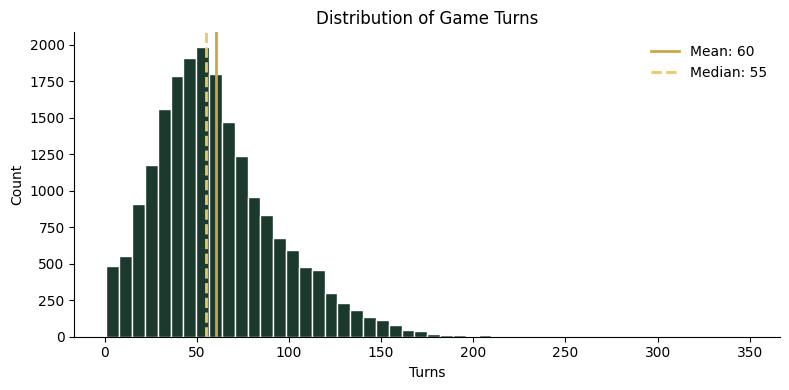

In [28]:
import matplotlib.pyplot as plt

# ── PLOT TURNS ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(games_cleaned['turns'], bins=50, color='#1B3A2D', edgecolor='white')
ax.axvline(games_cleaned['turns'].mean(), color='#C9A84C', lw=2, 
           label=f"Mean: {games_cleaned['turns'].mean():.0f}")
ax.axvline(games_cleaned['turns'].median(), color='#E8C96A', lw=2, ls='--',
           label=f"Median: {games_cleaned['turns'].median():.0f}")
ax.set_title('Distribution of Game Turns')
ax.set_xlabel('Turns')
ax.set_ylabel('Count')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
fig.tight_layout()
plt.savefig('../output/AQ1_turns_dist.png', dpi=150, bbox_inches='tight')

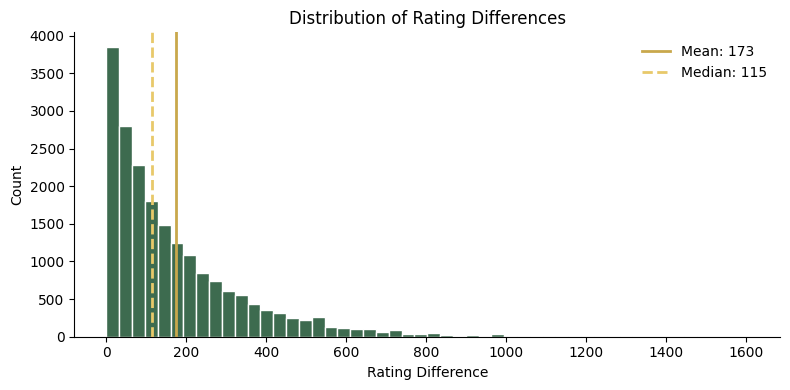

In [29]:
# ── PLOT RATING DIFF ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(games_cleaned['rating_diff'], bins=50, color='#3D6B4F', edgecolor='white')
ax.axvline(games_cleaned['rating_diff'].mean(), color='#C9A84C', lw=2,
           label=f"Mean: {games_cleaned['rating_diff'].mean():.0f}")
ax.axvline(games_cleaned['rating_diff'].median(), color='#E8C96A', lw=2, ls='--',
           label=f"Median: {games_cleaned['rating_diff'].median():.0f}")
ax.set_title('Distribution of Rating Differences')
ax.set_xlabel('Rating Difference')
ax.set_ylabel('Count')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
fig.tight_layout()
plt.savefig('../output/AQ1_rating_diff_dist.png', dpi=150, bbox_inches='tight')

- Conclusion:

From the data analysis, we can conclude that:

The turns variable has a mean of 60.47 and a standard deviation of 33.57, which indicates a relatively high variability in game length. Some games are very short while others are significantly longer.
The skewness (0.9) shows a moderate positive skew, meaning there are a few long games that increase the average number of turns.
For rating difference, the mean is 173.09 while the median is much lower (115), which suggests that most games are between similarly rated players, but there are some games with very large rating gaps.
The high standard deviation (179.21) and strong positive skewness (1.95) indicate a wide spread and strong right skew, meaning a small number of highly unbalanced games significantly affect the average.
Overall conclusion:

Both variables are positively skewed and highly variable, showing that while most games are relatively moderate in length and rating difference, a small number of extreme cases heavily influence the overall statistics.

## Log transform: 

In [32]:
import numpy as np
games_cleaned['sqrt_turns'] = np.sqrt(games_cleaned['turns'])
games_cleaned['sqrt_rating_diff'] = np.sqrt(games_cleaned['rating_diff'])

for col in ['sqrt_turns', 'sqrt_rating_diff']:

    q1 = games_cleaned[col].quantile(0.25)
    q3 = games_cleaned[col].quantile(0.75)

    print(f"\n----- {col} -----")
    print("Mean:", round(games_cleaned[col].mean(), 2))
    print("Median:", round(games_cleaned[col].median(), 2))
    print("Std:", round(games_cleaned[col].std(), 2))
    print("IQR:", round(q3 - q1, 2))
    print("Skewness:", round(games_cleaned[col].skew(), 2))


----- sqrt_turns -----
Mean: 7.45
Median: 7.42
Std: 2.22
IQR: 2.81
Skewness: -0.06

----- sqrt_rating_diff -----
Mean: 11.53
Median: 10.72
Std: 6.34
IQR: 8.82
Skewness: 0.62


- After applying the square root transformation, the distribution of the variables improved significantly. The skewness of the turns variable became approximately zero (-0.06), indicating an almost perfectly symmetric distribution. For rating difference, skewness decreased to 0.62, showing a substantial reduction in right skewness compared to the original data. Overall, the square root transformation provided a better balance than the log transformation and brought the data closer to a normal distribution.

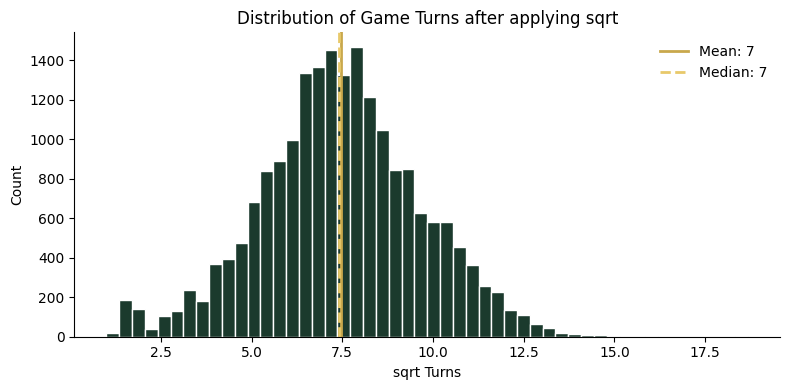

In [33]:
# ── PLOT TURNS AFTER SQRT─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(games_cleaned['sqrt_turns'], bins=50, color='#1B3A2D', edgecolor='white')
ax.axvline(games_cleaned['sqrt_turns'].mean(), color='#C9A84C', lw=2, 
           label=f"Mean: {games_cleaned['sqrt_turns'].mean():.0f}")
ax.axvline(games_cleaned['sqrt_turns'].median(), color='#E8C96A', lw=2, ls='--',
           label=f"Median: {games_cleaned['sqrt_turns'].median():.0f}")
ax.set_title('Distribution of Game Turns after applying sqrt')
ax.set_xlabel('sqrt Turns')
ax.set_ylabel('Count')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
fig.tight_layout()
plt.savefig('../output/AQ1_turns_dist_ after_sqrt.png', dpi=150, bbox_inches='tight')

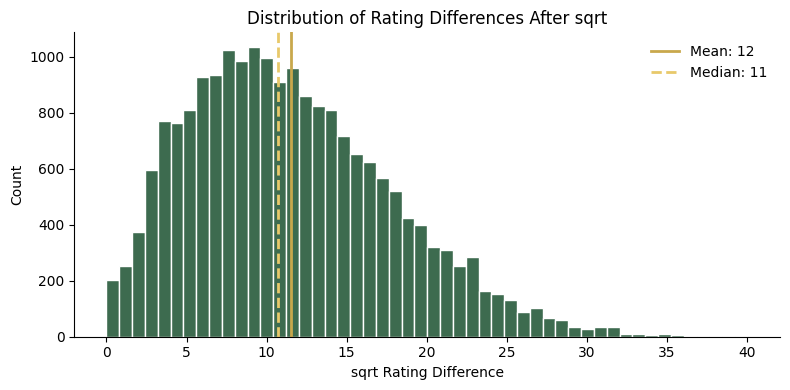

In [34]:
# ── PLOT RATING DIFF AFTER SQRT ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(games_cleaned['sqrt_rating_diff'], bins=50, color='#3D6B4F', edgecolor='white')
ax.axvline(games_cleaned['sqrt_rating_diff'].mean(), color='#C9A84C', lw=2,
           label=f"Mean: {games_cleaned['sqrt_rating_diff'].mean():.0f}")
ax.axvline(games_cleaned['sqrt_rating_diff'].median(), color='#E8C96A', lw=2, ls='--',
           label=f"Median: {games_cleaned['sqrt_rating_diff'].median():.0f}")
ax.set_title('Distribution of Rating Differences After sqrt')
ax.set_xlabel('sqrt Rating Difference')
ax.set_ylabel('Count')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
fig.tight_layout()
plt.savefig('../output/AQ1_rating_diff_dist_after_sqrt.png', dpi=150, bbox_inches='tight')

# Who Correlation Matrix

In [ ]:
WHO_URL = 'https://github.com/Priyankkoul/Life-Expectancy-WHO---Data-Analytics/blob/master/DATASET.csv?raw=true'
who = pd.read_csv(WHO_URL)
print("Shape:", who.shape)

Shape: (2938, 22)


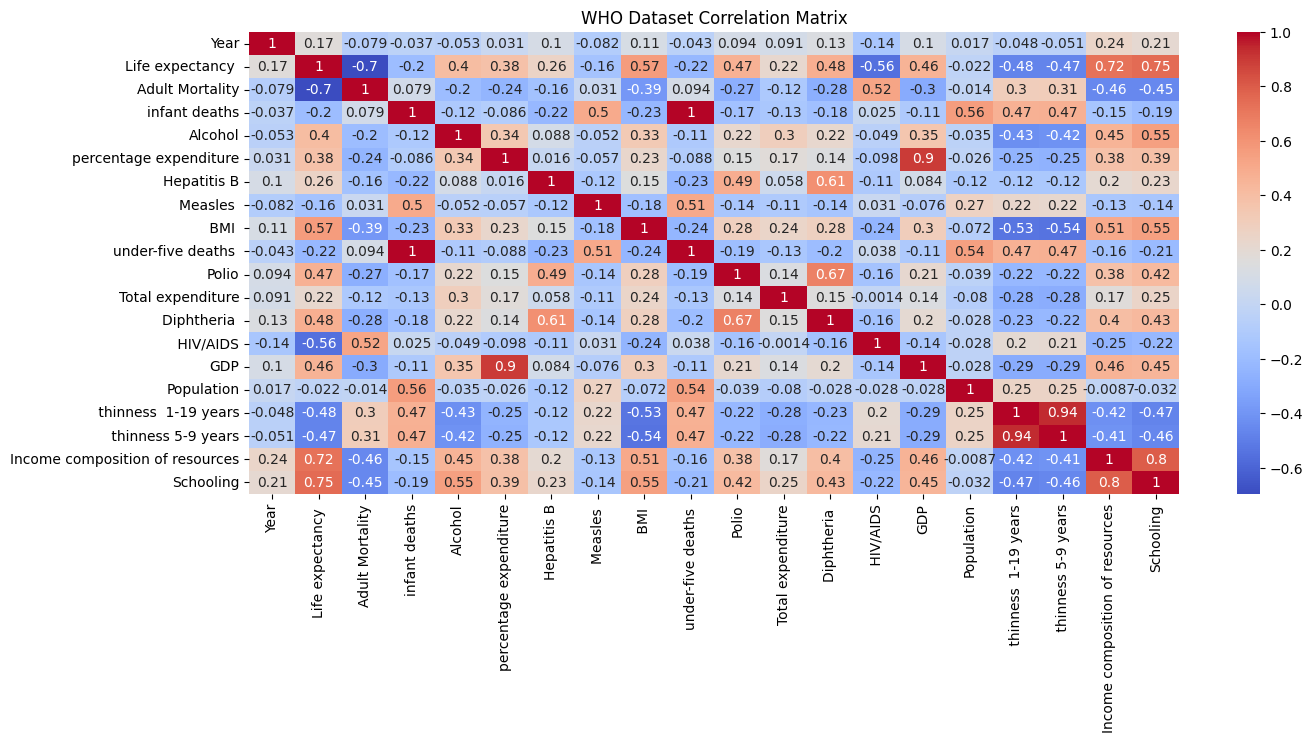

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = who.corr(numeric_only=True)

plt.figure(figsize=(15,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("WHO Dataset Correlation Matrix")
plt.show()

- Correlation Matrix:
The correlation matrix shows relationships between health and socioeconomic variables in the WHO dataset. Life expectancy has a strong positive correlation with schooling and income composition, and a negative correlation with HIV/AIDS and adult mortality. This indicates that better education and economic conditions are associated with higher life expectancy.

- Confounder:
A potential confounding variable is education (schooling). Education influences both income (GDP) and life expectancy, meaning it can create a misleading or inflated relationship between these variables if not considered. Countries with higher education levels tend to have better healthcare awareness and higher income, which improves overall life expectancy.

# CHI Squared Test

In [50]:
import pandas as pd
import numpy as np
from scipy import stats

games_cleaned['rating_group'] = pd.cut(
    games_cleaned['white_rating'],
    bins=[0, 1400, 1800, 3000],
    labels=['low', 'medium', 'high']
)

games_cleaned['win_white'] = (games_cleaned['winner'] == 'White').astype(int)

In [51]:
table = pd.crosstab(games_cleaned['rating_group'], games_cleaned['winner'])
print(table)

winner        Black  Draw  White
rating_group                    
low            2798   195   2102
medium         4495   440   5173
high           1814   315   2726


In [52]:
chi2, p, dof, expected = stats.chi2_contingency(table)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.6f}")

Chi-square: 333.766
p-value: 0.000000


In [54]:
high = games_cleaned[games_cleaned['rating_group'] == 'high']['win_white']
low = games_cleaned[games_cleaned['rating_group'] == 'low']['win_white']

pooled_std = np.sqrt((high.std()**2 + low.std()**2) / 2)

cohen_d = (high.mean() - low.mean()) / pooled_std

print(f"Cohen's d: {cohen_d:.3f}")

Cohen's d: 0.301


- The chi-square test indicates a statistically significant association between rating group and win rate (p < 0.05), meaning the variables are not independent. However, significance does not imply a strong relationship.

In [55]:
import numpy as np
from scipy import stats
from scipy.stats import t as t_dist

rated = games_cleaned[games_cleaned['rated'] == True]['turns']
unrated = games_cleaned[games_cleaned['rated'] == False]['turns']

In [56]:
def confidence_interval_diff(x, y, confidence=0.95):
    n1, n2 = len(x), len(y)
    m1, m2 = x.mean(), y.mean()

    se1 = x.std() / np.sqrt(n1)
    se2 = y.std() / np.sqrt(n2)

    diff = m1 - m2
    se_diff = np.sqrt(se1**2 + se2**2)

    t_crit = t_dist.ppf((1 + confidence) / 2., min(n1, n2) - 1)

    return diff - t_crit * se_diff, diff + t_crit * se_diff, diff

lo, hi, diff = confidence_interval_diff(rated, unrated)

print(f"Mean difference: {diff:.2f}")
print(f"Parametric 95% CI: ({lo:.2f}, {hi:.2f})")

Mean difference: 7.69
Parametric 95% CI: (6.56, 8.83)


In [ ]:
def bootstrap_ci_diff(x, y, n_boot=1000, confidence=0.95):
    rng = np.random.default_rng(42)
    diffs = []

    for _ in range(n_boot):
        x_sample = rng.choice(x, len(x), replace=True)
        y_sample = rng.choice(y, len(y), replace=True)
        diffs.append(np.mean(x_sample) - np.mean(y_sample))

    a = (1 - confidence) / 2
    return np.percentile(diffs, [a*100, (1-a)*100])

lo_b, hi_b = bootstrap_ci_diff(rated.values, unrated.values)

print(f"Bootstrap 95% CI: ({lo_b:.2f}, {hi_b:.2f})")

Bootstrap 95% CI: (6.61, 8.97)


: 

- Rated games are significantly longer than unrated games, with an average increase of approximately 7.69 turns.
- The parametric 95% confidence interval for the mean difference is (6.56, 8.83), while the bootstrap 95% confidence interval is (6.61, 8.97). Both intervals are entirely above zero, confirming that the difference is statistically reliable and consistent across both methods.
- This indicates that rated games tend to last more moves than unrated games. However, while the difference is statistically significant, the magnitude is relatively modest in practical terms.